# <center> TP2 : Reconnaissance de Formes </center>

## <center> Extraction de descripteurs et Mesures de Similarité</center>



# Partie I
## 1) Descripteurs de forme

L'objectif principal de la description de région est d'obtenir une représentation mathématique d'une région segmentée à partir d'une image consistant en un vecteur de caractéristiques $\mathbf{x}=[x_1,\dots,x_n]$.  

<img src="./images/region_description_sample.png" width="450">

Dans cette 1ère partie, nous allons voir une branche de la description de région appelée **analyse de forme**. Elle vise à construire un vecteur de caractéristiques en utilisant uniquement des caractéristiques de forme (par exemple, taille, périmètre, circularité et compacité).  

Selon l'application, il peut être nécessaire que le descripteur utilisé soit **invariant** à la position dans l'image où apparaissent les régions, à leur orientation et/ou à leur taille (échelle). Quelques exemples :

<img src="./images/invariances.png" width="650">

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib

from numpy.linalg import eig
from scipy.linalg import sqrtm
from matplotlib import patches



matplotlib.rcParams['figure.figsize'] = (15.0, 8.0)

images_path = './images/'

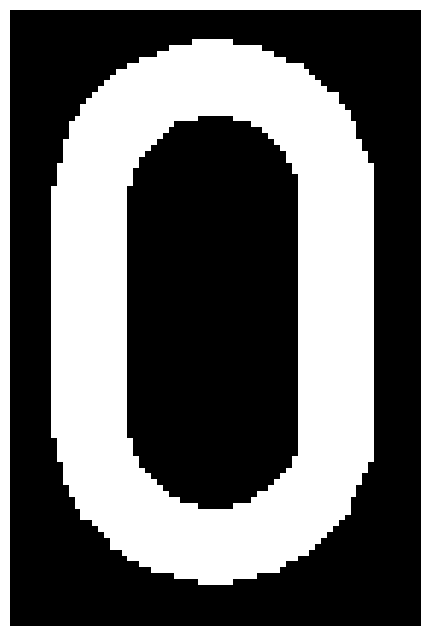

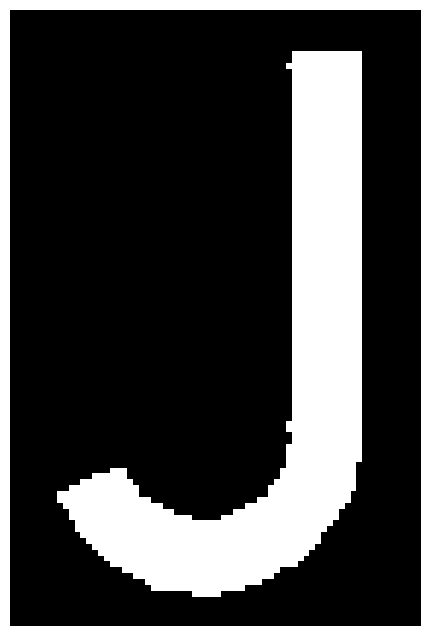

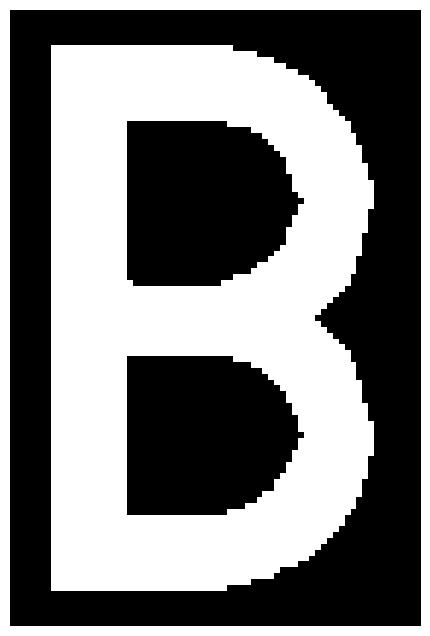

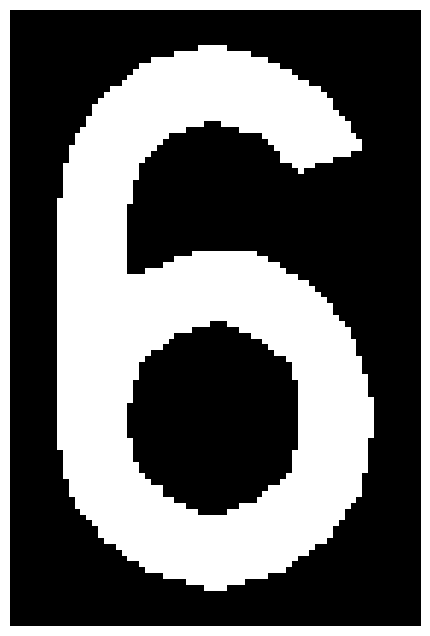

In [ ]:
# Lire les images : region_0.png, region_J.png, region_B.png et region_6.png 

# Affichage des images
images = ["region_0.png", "region_J.png", "region_B.png", "region_6.png"]
for image in images:
    i = cv2.imread(images_path + image)

    plt.imshow(i)
    plt.axis('off')
    plt.show()

### 1.1 Compacité

La première caractéristique avec laquelle nous allons travailler est la **compacité**:$\\[5pt]$

$$\textbf{compacité} = \frac{aire}{périmètre^2}$$


$\\[5pt]$

Comme vous pouvez le voir, cette caractéristique associe l'aire avec le périmètre d'une région. De manière informelle, elle indique à quel point une région est *arrondie* et *fermée*. La forme la plus compacte est le cercle, avec $\textbf{compacité} = 1 / (4\pi)$.

<img src="./images/compactness.png" width="300">

$\\[5pt]$

#### **<span style="color:green"><b><i>Exercice 1 : Calcul de la compacité</i></b></span>**

**Que faire ?** Complétez la fonction ci-dessous, nommée `compacite()`, qui calcule la compacité d'une région en entrée.

Pour cela, nous allons utiliser la fonction [`cv2.findContours()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0) 
<!--, qui prend en entrée :

- Une image binaire (contenant la région sous forme de pixels blancs).
- Le mode de récupération des contours, qui peut être :$\\[5pt]$
    - `RETR_EXTERNAL` : ne renvoie que le contour externe
    - `RETR_LIST` : renvoie tous les contours (par exemple, le caractère 0 contiendrait deux contours : externe et interne)
    - `RETR_CCOMP` : renvoie tous les contours et les organise en une hiérarchie à deux niveaux. Au niveau supérieur, il y a les limites externes des composants. Au deuxième niveau, il y a les limites des trous.$\\[5pt]$
- Méthode : contrôle le nombre de points des contours qui sont stockés, ceci pour des raisons d'optimisation.$\\[5pt]$
    - `CHAIN_APPROX_NONE` : stocke absolument tous les points du contour.
    - `CHAIN_APPROX_SIMPLE` : compresse les segments horizontaux, verticaux et diagonaux et ne laisse que leurs points finaux.
    - `CHAIN_APPROX_TC89_L1` : applique un algorithme d'optimisation.
    
Et renvoie :

- une liste contenant les contours,
- et une liste contenant des informations sur la topologie de l'image. Elle a autant d'éléments que de contours.

Pour simplifier, nous allons prendre en compte **seulement la limite externe** (comme si les régions n'avaient pas de trous), donc la deuxième sortie n'est pas pertinente.

-->
En ayant les contours, vous pouvez obtenir la **surface** et le **périmètre** de la région via [`cv2.contourArea()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga2c759ed9f497d4a618048a2f56dc97f1) et [`cv2.arcLength()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga8d26483c636be6b35c3ec6335798a47c). Les deux fonctions prennent les contours de la région en entrée.

In [5]:
zero = cv2.imread(images_path + "region_0.png", cv2.IMREAD_GRAYSCALE)
J = cv2.imread(images_path + "region_J.png", cv2.IMREAD_GRAYSCALE)
B = cv2.imread(images_path + "region_B.png", cv2.IMREAD_GRAYSCALE)
six = cv2.imread(images_path + "region_06.png", cv2.IMREAD_GRAYSCALE)

In [ ]:
# A compléter ...

# Assurez-vous que la fonction de compacité est définie
def compacite(region):
    """ Calcule la compacité d'une région.   
    
        Args:
            region: Image binaire (région blanche sur fond noir)
                    
        Returns: 
            Compacité de la région (valeur entre 0 et 1/4pi)
    """   
    # Extraire le(s) contour(s) de la région 
    contours_data = cv2.findContours(region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_data[0] if len(contours_data) == 2 else contours_data[1]

    if len(contours) == 0:
        return 0.0
    
    contour = max(contours, key=cv2.contourArea)
    # Calculer l'aire du contour (l'aire de la région)
    area = cv2.contourArea(contour)

    # Calculer le périmètre du contour
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return 0.0
    
    # Calculer la compacité (4 * pi * area / perimeter^2)
    valeur = (4 * np.pi * area) / (perimeter ** 2)
    
    return valeur

# Et afficher leur compacité !
print(" Compacité de 0 : ", round(compacite(zero), 5), "\n",
      "Compacité de J : ", round(compacite(J), 5), "\n",
      "Compacité de B : ", round(compacite(B), 5), "\n",
      "Compacité de 6 : ", round(compacite(six), 5))

 Compacité de 0 :  0.82792 
 Compacité de J :  0.22803 
 Compacité de B :  0.7131 
 Compacité de 6 :  0.0


### 1.2 Étendue

Un autre descripteur de forme est l'**étendue** d'une forme: $\\[5pt]$

$$
\textbf{étendue} = \frac{aire}{aire\ du\ rectangle\ englobant}
$$

$\\[5pt]$

Cette caractéristique associe l'aire de la région avec l'aire de son rectangle englobant. Un **rectangle englobant** peut être défini comme le plus petit rectangle qui contient tous les pixels d'une région dont le bord inférieur est horizontal et le bord gauche est vertical.

<img src="./images/bounding.png" width="400">

La forme avec la valeur d'étendue la plus élevée est le rectangle, avec $étendue=1$, tandis que la plus basse est une région vide donc $étendue=0$.

#### **<span style="color:green"><b><i>Exercice 2 : Temps de calcul de l'étendue</i></b></span>**

Complétez la fonction `etendue()`, qui reçoit la `region` à décrire en entrée et renvoie son `étendue`.

*Astuce : calculez le rectangle englobant en utilisant [cv2.boundingRect()](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga103fcbda2f540f3ef1c042d6a9b35ac7), qui prend également les contours en entrée.*

In [11]:
# A compléter ...

def etendue(region):
    """ Calcule l'étendue d'une région.   
    
        Args:
            region: Image binaire (région blanche sur fond noir)
                    
        Returns: 
            etendue: Étendue de la région (valeur entre 0 et 1)
    """   
    _, region = cv2.threshold(region, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Extraire le(s) contour(s) de la région 
    contours_data = cv2.findContours(region, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_data[0] if len(contours_data) == 2 else contours_data[1]

    if not contours:
        return 0.0
    
    contour = max(contours, key=cv2.contourArea)
    
    # Calculer l'aire du contour (l'aire de la région)
    area = cv2.contourArea(contour)
    
    # Obtenir le rectangle englobant (x, y, largeur, hauteur)
    x, y, w, h = cv2.boundingRect(contour)
    
    # Calculer l'aire du rectangle englobant
    rect_area = w * h

    if rect_area == 0:
        return 0.0

    valeur = area / rect_area
    
    return valeur

In [12]:
# And show their extent!
print(" Etendue of 0: ", round(etendue(zero),5), "\n",
      "Etendue of J: ", round(etendue(J),5), "\n",
      "Etendue of B: ", round(etendue(B),5), "\n",
      "Etendue of 6: ", round(etendue(six),5))

 Etendue of 0:  0.84203 
 Etendue of J:  0.2866 
 Etendue of B:  0.87937 
 Etendue of 6:  0.0


### 1.3 Construction d'un vecteur de caractéristiques

Maintenant que nous pouvons calculer deux caractéristiques différentes, la compacité ($x_1$) et l'étendue ($x_2$), nous pouvons construire un vecteur de caractéristiques ($\mathbf{x}$) pour caractériser chaque région en concaténant les deux caractéristiques, c'est-à-dire, $\mathbf{x}=[x_1,x_2]$.


#### **<span style="color:green"><b><i>Exercice 3 : Tracer les vecteurs de caractéristiques</i></b></span>**

**Votre tâche est** de tracer les vecteurs de caractéristiques, calculés par les fonctions `compacite()` et `etendue()`, dans un espace 2D. Dans cet espace, **l'axe des x représente la compacité** d'une région et **l'axe des y son étendue**.

De cette manière, si les descriptions des caractères considérés dans cet espace n'apparaissent pas proches les unes des autres, cela signifie qu'ils peuvent être différenciés en se basant sur ces caractéristiques. **Le problème apparaît si deux ou plusieurs caractères ont des caractéristiques similaires** (leurs points respectifs sont proches). Cela nous indique que **ces caractéristiques ne sont tout simplement pas suffisantes** pour détecter automatiquement les caractères de la plaque.

*Astuce : [introduction à pyplot](https://matplotlib.org/tutorials/introductory/pyplot.html)*.

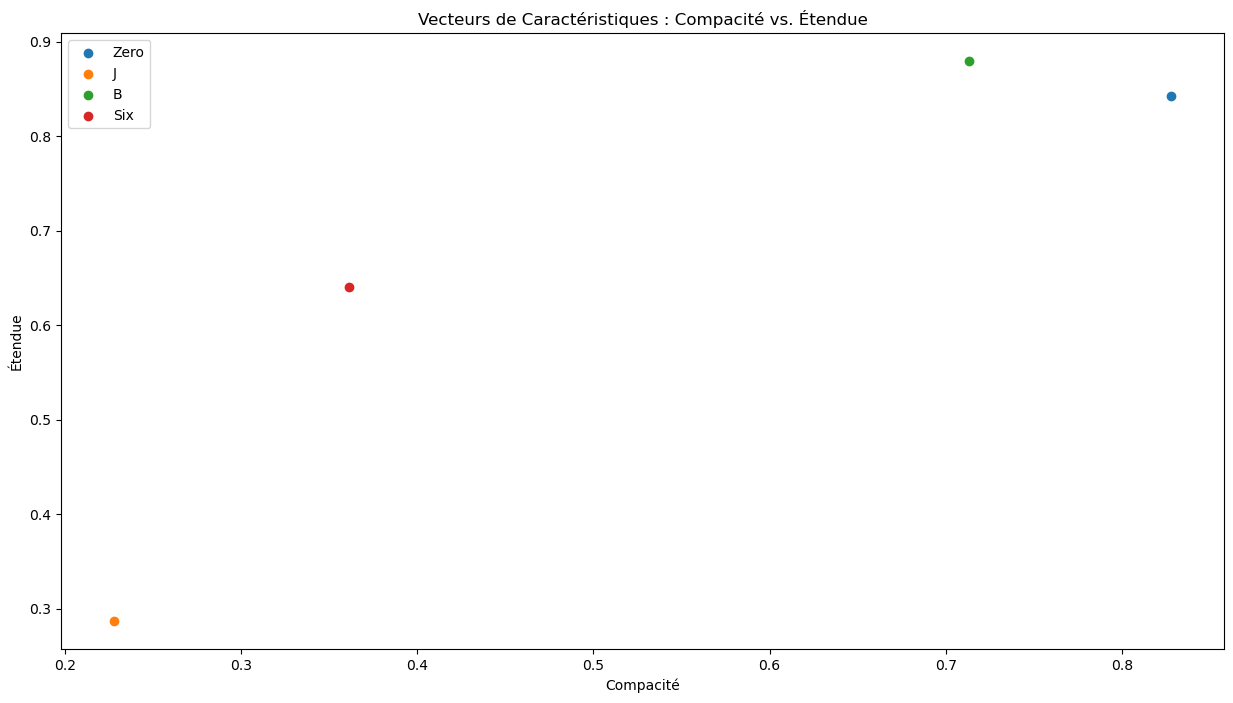

In [1061]:
# A compléter ...

# Calculer les vecteurs de caractéristiques (compacité et étendue)
vecteurs_caracteristiques = []
# A compléter ...  ==>  # [x1 (compacité), x2 (étendue), label]

# Préparer les données pour le tracé
x1 = [vc[0] for vc in vecteurs_caracteristiques]  # Valeurs de compacité
x2 = [vc[1] for vc in vecteurs_caracteristiques]  # Valeurs d'étendue
labels = [vc[2] for vc in vecteurs_caracteristiques]  # Étiquettes des régions

# Créer le graphique 
# Afficher le graphique


plt.show()


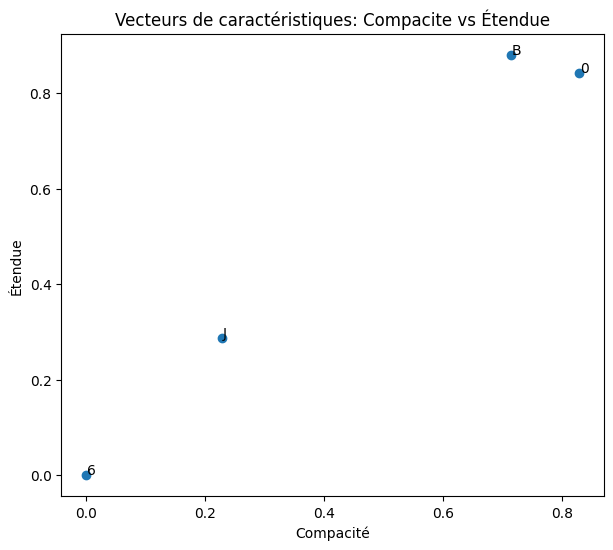

In [14]:
# A compléter ...

# Calculer les vecteurs de caractéristiques (compacité et étendue)
vecteurs_caracteristiques = []
# A compléter ...  ==>  # [x1 (compacité), x2 (étendue), label]
vecteurs_caracteristiques = [
    [compacite(zero), etendue(zero), "0"],
    [compacite(J), etendue(J), "J"],
    [compacite(B), etendue(B), "B"],
    [compacite(six), etendue(six), "6"]
]

# Préparer les données pour le tracé
x1 = [vc[0] for vc in vecteurs_caracteristiques]  # Valeurs de compacité
x2 = [vc[1] for vc in vecteurs_caracteristiques]  # Valeurs d'étendue
labels = [vc[2] for vc in vecteurs_caracteristiques]  # Étiquettes des régions

# Créer le graphique 
# Afficher le graphique
plt.figure(figsize=(7,6))
plt.scatter(x1, x2)

for i, label in enumerate(labels):
    plt.text(x1[i] + 0.002, x2[i] + 0.002, label)

plt.xlabel("Compacité")
plt.ylabel("Étendue")
plt.title("Vecteurs de caractéristiques: Compacite vs Étendue")

plt.show()


## 2) Description du contenu des régions

Contrairement aux techniques de description de forme, qui travaillent avec les contours des régions, la description du contenu des régions se concentre sur la caractérisation du contenu des régions segmentées à travers leur distribution dans l'image, leurs textures, etc. 
<!--
En ce qui concerne les textures, elles nous donnent des informations sur la disposition spatiale des couleurs ou des intensités dans une image ou une région sélectionnée d'une image. Les textures peuvent être utilisées pour aider à la segmentation ou à la classification des images. Notez que ces méthodes ne nécessitent pas d'images binaires en entrée. 

Ce notebook couvre différentes techniques de description du contenu des régions :

- Moments d'image 2D (section 2.1)
- Moments de Hu (section 2.2)
- Moments de l'histogramme de l'image (section 2.3.1)
- Matrices de co-occurrence (section 2.3.2)

Vous utiliserez certaines méthodes de description des régions appliquées à ce problème, comme les **matrices de co-occurrence** ou les **moments de l'histogramme de l'image**. 

-->

### 2.1 Moments d'image

Un **moment d'image** (moment 2D) est une moyenne pondérée (ou moment) de l'intensité des pixels dans l'image/région, ou une fonction combinant d'autres moments. Les moments ont généralement une propriété ou une interprétation attrayante, et ils peuvent fonctionner à la fois sur des images en niveaux de gris et en couleur. Il existe 3 types principaux de moments :

- **Moments non centraux :**$\\[3pt]$

$\hspace{2cm}m_{ij} = \sum_{y=1}^{cols}\sum_{x=1}^{rows}x^i y^j I(x,y)$

- **Moments centraux :**

  $\hspace{1.2cm}\mu_{ij} = \sum_{y=1}^{cols}\sum_{x=1}^{rows}(x-\overline{x})^i (y-\overline{y})^j I(x,y)$ 
  $\\[2pt]$<br />
  où : <br />
    - $\left(\overline{x},\overline{y}\right) = \left(\frac{m_{10}}{m_{00}} ,\frac{m_{01}}{m_{00}} \right)$ est le centroïde de la région $\\[3pt]$
    - $I(x,y)$ signifie l'intensité du pixel aux coordonnées $(x, y)$ de l'image $I$.
 
  Lorsqu'on travaille avec de grandes images/régions, il est possible de gagner du temps de calcul en utilisant les moments non centraux pour calculer les moments centraux :

$
\hspace{2cm}\mu_{00} = m_{00} \equiv \mu \\
\hspace{2cm}\mu_{01} = 0 \\
\hspace{2cm}\mu_{10} = 0 \\
\hspace{2cm}\mu_{20} = m_{20} - \mu \overline{x}^2\\
\hspace{2cm}\mu_{11} = m_{11} - \mu \overline{xy}\\
\hspace{2cm}\mu_{02} = m_{02} - \mu \overline{y}^2\\
\hspace{2cm}\mu_{30} = m_{30} - 3m_{20} \overline{x} + 2 \mu \overline{x}^3 \\
\hspace{2cm}\mu_{21} = m_{21} - m_{20} \overline{y} - 2m_{11} \overline{x} + 2\mu \overline{x}^2\overline{y} \\
\hspace{2cm}\mu_{12} = m_{12} - m_{02} \overline{x} - 2m_{11} \overline{y} + 2\mu \overline{y}^2\overline{x}\\
\hspace{2cm}\mu_{03} = m_{03} - 3m_{02} \overline{y} + 2 \mu \overline{y}^3\\[3pt] 
$

- **Moments invariants à l'échelle :**$\\[3pt]$

$\hspace{2cm} \eta_{ij} = \mu_{ij}\ /\ \mu_{00}^{1+((i+j)/2)}$

$\hspace{2cm}$ où $i + j \ge 2$.


OpenCV définit une méthode pour calculer certains moments centraux, non centraux et invariants à l'échelle appelée [`cv2.moments()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga556a180f43cab22649c23ada36a8a139), qui prend en entrée :

- pour les images d'intensité : un contour (tableau de points 2D) délimitant les régions segmentées.
- pour les images en niveaux de gris : l'image elle-même.

Cette fonction renvoie un dictionnaire contenant ces moments.

#### **<span style="color:green"><b><i>Exercie 4 : Calcul des moments d'image</i></b></span>**

**Que faire ?** Votre première tâche consiste à compléter la méthode `image_moments()`, qui applique la méthode [`cv2.moments()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga556a180f43cab22649c23ada36a8a139) à une image binaire.

In [17]:
# A compléter ...

def image_moments(region):
    """ Calcule les moments de la région dans une image binaire.
        Args:
            region: Image binaire (région blanche sur fond noir)       
        Returns: 
            moments: dictionnaire contenant les moments non centraux, centraux et invariants à l'échelle
    """
    
    # A compléter ...
    _, binary = cv2.threshold(region, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    moments = cv2.moments(binary)

    return moments
    
region = np.array([[255,255,255,255,255],[255,0,0,0,255],[255,0,0,255,255],[255,0,255,255,255],[0,0,255,255,255]], dtype=np.uint8)
moments = image_moments(region)

# Round moments for visualization matters
for k, v in moments.items():
    moments[k] = round(v,2)

print(moments)

{'m00': 4335.0, 'm10': 9945.0, 'm01': 8160.0, 'm20': 32895.0, 'm11': 20655.0, 'm02': 24990.0, 'm30': 115515.0, 'm21': 68595.0, 'm12': 65535.0, 'm03': 83130.0, 'mu20': 10080.0, 'mu11': 1935.0, 'mu02': 9630.0, 'mu30': -6199.41, 'mu21': -2203.24, 'mu12': 920.29, 'mu03': -164.12, 'nu20': 0.0, 'nu11': 0.0, 'nu02': 0.0, 'nu30': -0.0, 'nu21': -0.0, 'nu12': 0.0, 'nu03': -0.0}


### 2.2 Moments de Hu

Les **moments de Hu** (publiés en 1962 par Ming-Kuei Hu) sont un ensemble de 7 moments particuliers calculés en utilisant l'invariance d'échelle. Concrètement, ils sont calculés en utilisant les équations suivantes :

$
\hspace{2cm}v_{1} = \eta_{20} + \eta_{02} \\
\hspace{2cm}v_{2} = (\eta_{20} - \eta_{02}) + 4\eta_{11}^2 \\
\hspace{2cm}v_{3} = (\eta_{20} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2 \\
\hspace{2cm}v_{4} = (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2\\
\hspace{2cm}v_{5} = (\eta_{30}-3\eta_{12})(\eta_{30}+\eta_{12})[(\eta_{30}+\eta_{12})^2 -3(\eta_{21}+\eta_{03})^2] + (3\eta_{21}-\eta_{03})(\eta_{21}+\eta_{03})[3(\eta_{30}+\eta_{12})^2-(\eta_{21} + \eta_{03})^2]\\
\hspace{2cm}v_{6} = (\eta_{20}-\eta_{02})[(\eta_{30}+\eta_{12})^2 -(\eta_{21}-\eta_{03})^2 + 4\eta_{11} (\eta_{30}+\eta_{12})(\eta_{21}+\eta_{03})] \\
\hspace{2cm}v_{7} = (3\eta_{21}-\eta_{03})(\eta_{30}+\eta_{12})[(\eta_{30}+\eta_{12})^2-3(\eta_{30}+\eta_{12})^2]+(\eta_{30}-3\eta_{12})(\eta_{21}+\eta_{03})[3(\eta_{30}+\eta_{12})^2-(\eta_{21}+\eta_{03})^2]\\
$


OpenCV fournit une méthode pour récupérer les moments de Hu, appelée [`cv2.moments()`](https://docs.opencv.org/4.2.0/d3/dc0/group__imgproc__shape.html#ga556a180f43cab22649c23ada36a8a139) ! Cette méthode prend en entrée le dictionnaire des moments retourné par `cv2.moments`. 

In [18]:
def image_moments(image):
    # A compléter ...
    # Application sur le contour de l'image
    _, binary = cv2.threshold(image, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(binary,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    
    contour = max(contours, key=cv2.contourArea)
        
    # Calcul des moments
    moments = cv2.moments(contour)
    
    # Calcul des moments de Hu (invariants)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    return moments, hu_moments

# Exemple d'image binaire (vous pouvez charger une vraie image avec cv2.imread)
image = np.array([[255, 255, 255, 255, 255],
                  [255, 0, 0, 0, 255],
                  [255, 0, 0, 255, 255],
                  [255, 0, 255, 255, 255],
                  [0, 0, 255, 255, 255]], dtype=np.uint8)

# Calcul des moments et moments de Hu
moments, hu_moments = image_moments(image)

if moments is not None:
    print("Moments:", moments)
    print("Hu Moments:", hu_moments)
else:
    print("Aucun contour trouvé dans l'image.")


Moments: {'m00': 5.0, 'm10': 14.666666666666666, 'm01': 12.0, 'm20': 48.166666666666664, 'm11': 37.0, 'm02': 36.166666666666664, 'm30': 163.4, 'm21': 119.16666666666667, 'm12': 111.13333333333333, 'm03': 116.0, 'mu20': 5.144444444444439, 'mu11': 1.7999999999999972, 'mu02': 7.36666666666666, 'mu30': -8.069629629629588, 'mu21': -6.993333333333316, 'mu12': -3.595555555555549, 'mu03': -6.159999999999982, 'nu20': 0.2057777777777776, 'nu11': 0.0719999999999999, 'nu02': 0.29466666666666647, 'nu30': -0.1443539232407857, 'nu21': -0.12510054978118795, 'nu12': -0.06431925311279384, 'nu03': -0.11019342993118933}
Hu Moments: [ 0.50044444  0.02863723  0.0726447   0.09890775  0.00593813  0.01519122
 -0.00591852]


#### **<span style="color:green"><b><i>Exercice 5 : Explorer les invariances des moments de Hu</i></b></span>**

 Maintenant, **nous nous intéressons à vérifier les invariances des moments de Hu**. 

Pour cela, complétez la fonction `compare_moments()` de la même manière que dans les exercices précédents.

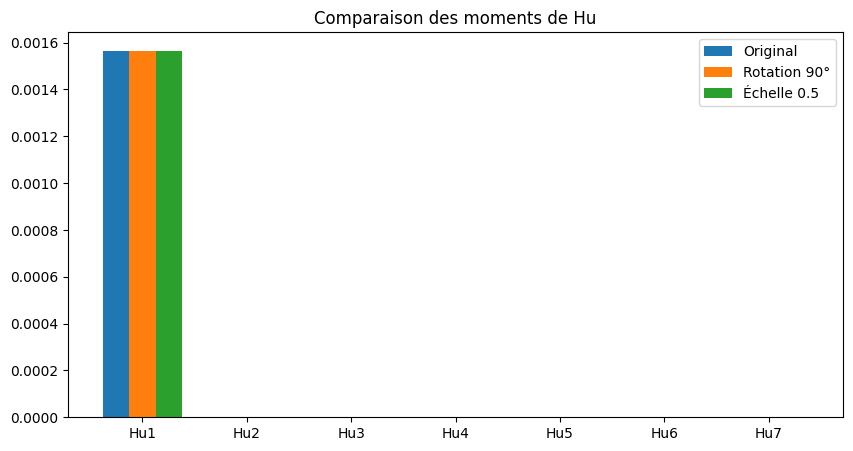

In [20]:
def moments_image(region):
    """ Calculer les moments de la région dans une image binaire.   
    
        Args:
            region: Image binaire (niveaux de gris)
                    
        Returns: 
            moments: Dictionnaire contenant les moments non centraux, centraux et de Hu
    """   
    
    # Calculer les moments
    moments = cv2.moments(region)

    # Calculer les moments non centraux (les 10 premiers moments)
    moments_non_centraux = {
        'm00': moments['m00'] ,
        'm10': moments['m10'] ,
        'm01': moments['m01'] ,
        'm11': moments['m11'] ,
        'm20': moments['m20'] ,
        'm21': moments['m21'] ,
        'm02': moments['m02'] ,
        'm30': moments['m30'] , 
        # 'm31': moments['m31'] ,
        'm03': moments['m03'] ,
    }

    # Calculer les moments centraux
    cx = moments['m10'] / moments['m00']
    cy = moments['m01'] / moments['m00']
    
    moments_centraux = {
        'mu20': moments['mu20'],
        'mu11': moments['mu11'],
        'mu02': moments['mu02'],
        'mu30': moments['mu30'],
        'mu21': moments['mu21'],
        'mu12': moments['mu12'],
        'mu03': moments['mu03'],
    }

    # Calculer les moments de Hu
    # A compléter ...
    moments_hu = cv2.HuMoments(moments).flatten()

    # Retourner tous les moments sous forme de dictionnaire
    return {
        'non_centraux': moments_non_centraux,
        'centraux': moments_centraux,
        'hu': moments_hu
    }

def comparer_moments_hu(region):
    """ Comparer les moments de Hu des régions originales, tournées et mises à l'échelle. """
    
    # Étape 1 : Calculer les moments de Hu pour l'image originale
    moments_originaux = moments_image(region)
    moments_hu_originaux = moments_originaux['hu']
    
    # Étape 2 : Tourner l'image de 90 degrés et calculer les moments de Hu
    region_tournee = cv2.rotate(region, cv2.ROTATE_90_CLOCKWISE)
    moments_tournes = moments_image(region_tournee)
    moments_hu_tournes = moments_tournes['hu']
    
    # Étape 3 : Mettre l'image à l'échelle (par exemple, redimensionner par un facteur de 0,5)
    region_mise_a_echelle = cv2.resize(region, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    moments_mise_a_echelle = moments_image(region_mise_a_echelle)
    moments_hu_mise_a_echelle = moments_mise_a_echelle['hu']
    
    # Étape 4 : Tracer les moments de Hu pour comparaison
    etiquettes = [f'Hu{i+1}' for i in range(7)]
    
    x = np.arange(7)
    width = 0.25

    # Diagramme en barres pour les moments de Hu originaux
    # A compléter ... 
    plt.figure(figsize=(10, 5))
    plt.bar(x - width, moments_hu_originaux, width, label='Original')
    plt.bar(x, moments_hu_tournes, width, label='Rotation 90°')
    plt.bar(x + width, moments_hu_mise_a_echelle, width, label='Échelle 0.5')

    plt.xticks(x, etiquettes)
    plt.title("Comparaison des moments de Hu")
    plt.legend()
    plt.show()


chemin_image = './images/region_0.png'  
region = cv2.imread(chemin_image, 0)  # Lire en tant qu'image en niveaux de gris (binaire)

# Appeler la fonction pour comparer les moments de Hu
comparer_moments_hu(region)


### 3) Fonctions discriminantes

Nous avons exploré comment extraire un vecteur de caractéristiques $\textbf{x} = [x_1, x_2, \ldots, x_n]$ pour décrire un objet d'image ou une *région* (par exemple, une région binaire, une image segmentée, $\ldots$).

Maintenant, notre objectif est **de classifier l'objet comme appartenant à l'une des $M$ classes ou catégories d'objets**, en fonction de son vecteur de caractéristiques $\textbf{x}$. Pour cela, l'espace défini par les caractéristiques de $\textbf{x}$, également appelé **espace des caractéristiques**, est divisé en régions de prédiction. L'image ci-dessous montre un exemple de ces régions dans un scénario avec des catégories $C=\{C_1,C_2,C_3\}$, donc $M=3$, et des caractéristiques $\textbf{x}=[x_1,x_2]$ :

$\\[10pt]$


<img src="clas-space.png"  width="300"  >


$\\[3pt]$

Deux étapes principales sont nécessaires pour construire un système de reconnaissance d'objets et travailler avec :

- Une **phase d'entraînement (conception)**, où des vecteurs d'échantillons d'objets connus sont utilisés pour apprendre le classificateur (apprentissage supervisé).
- Une **phase de prédiction (en ligne)**, où les objets d'image sont classés dans l'une des classes en fonction des modèles de prédiction appris.

Ces modèles de prédiction se présentent sous deux formes :

- **classifieurs statistiques :**
  - On suppose que les vecteurs de caractéristiques $\textbf{x}$ des classes $C$ suivent une **distribution statistique**.
  - Les paramètres de cette distribution doivent être **appris à partir d'objets connus**.
  - Exemples : Classificateur Bayésien Naïf, Régression Logistique, Champs Aléatoires Conditionnels.
- **classifieurs non statistiques :**
  - Aucune hypothèse n'est faite sur la distribution statistique du vecteur de caractéristiques.
  - Les coefficients des fonctions discriminantes déterministes sont appris.
  - Exemples : Machine à Vecteurs de Support, Perceptron, AdaBoost.
<!--
Ce notebook se concentre sur les classifieurs non statistiques. Concrètement, il couvre :

- Fonctions discriminantes linéaires (section 3.1.1).
- Séparabilité (section 3.1.2).
- Fonction discriminante généralisée (section 3.1.3). -->


#### Bases de données

Ici, on va s'intéresser aux trois formes : rectangulaire, circulaire et  triangulaire :

- `./images/circles/{0-19}.png`
- `./images/rectangles/{0-19}.png`
- `./images/triangles/{0-19}.png`

<!-->
Ces dossiers contiennent des images segmentées et binarisées de panneaux de signalisation capturées par une caméra dans une voiture. **Notre tâche est de concevoir un système de reconnaissance capable de distinguer chaque type de forme.**
-->

### Calcul des vecteurs de caractéristiques

Avant de décrire les méthodes qui seront utilisées pour effectuer la reconnaissance, construisons les vecteurs de caractéristiques qu'elles vont utiliser. Pour cela, vous allez utiliser les Moments de Hu (vecteur de caractéristiques de taille 7).

#### **<span style="color:green"><b><i>Exercice 6</i></b></span>**

**Votre tâche est** d'obtenir une matrice $20x7$ pour chaque type de forme, où les lignes indexent les images et les colonnes les moments de Hu. De cette manière, la $5^{ème}$ ligne de la matrice caractérisant les panneaux rectangulaires contiendrait les moments de Hu calculés à partir de la $5^{ème}$ image de cette forme.

Afin d'obtenir une première impression de la manière dont ces caractéristiques sont distribuées dans l'espace des caractéristiques pour les différentes formes, tracez les résultats en utilisant [`plt.scatter()`](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.scatter.html) (montrez uniquement les 2 premiers moments de Hu).

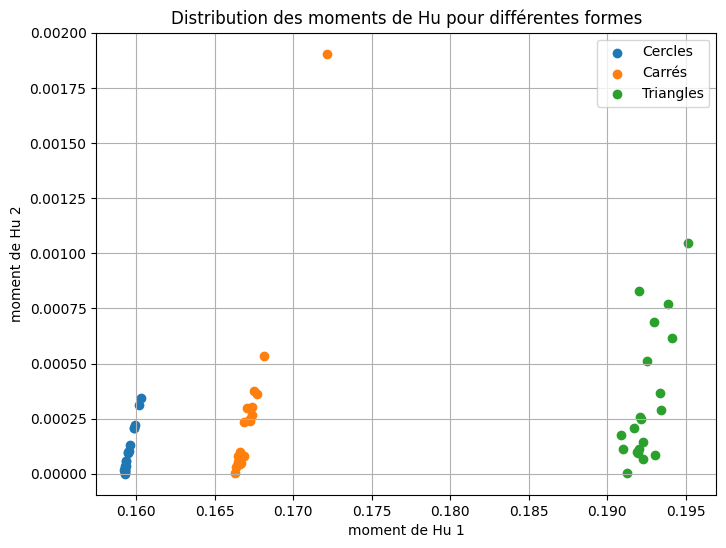

In [24]:
# Chargement des moments de Hu pour chaque classe (Cercle, Carré, Triangle)
data_path = './data/'
# class_1_moments = np.load(data_path + 'hu_circles.npy')  # Moments des cercles
class_1_moments = np.load(data_path + 'hu_circles.npy')
class_2_moments = np.load(data_path + 'hu_squares.npy')  # Moments des carrés
class_3_moments = np.load(data_path + 'hu_triangles.npy')  # Moments des triangles

# Utilisation uniquement des deux premiers moments de Hu (premières 2 composantes)
# A compléter ...
class_1_moments = class_1_moments[:, :2]
class_2_moments = class_2_moments[:, :2]
class_3_moments = class_3_moments[:, :2]

# Combiner toutes les données de classe en une seule matrice (chaque ligne est un point de données)
X = np.vstack((class_1_moments, class_2_moments, class_3_moments))

# Labels correspondants à chaque classe (0 = Cercle, 1 = Carré, 2 = Triangle)
y = np.hstack((
    np.zeros(len(class_1_moments)),      # Cercles
    np.ones(len(class_2_moments)),       # Carrés
    np.full(len(class_3_moments), 2)     # Triangles
))

# Affichage des moments de Hu (2 premiers moments)
# Afficher le graphique
plt.figure(figsize=(8,6))

plt.scatter(class_1_moments[:,0], class_1_moments[:,1], label="Cercles")
plt.scatter(class_2_moments[:,0], class_2_moments[:,1], label="Carrés")
plt.scatter(class_3_moments[:,0], class_3_moments[:,1], label="Triangles")

plt.xlabel("moment de Hu 1")
plt.ylabel("moment de Hu 2")
plt.title("Distribution des moments de Hu pour différentes formes")
plt.legend()
plt.grid()

plt.show()


In [25]:
# A compléter ...
chemin_images = "./images/"

# Calculer les matrices de covariance pour chaque classe (basé sur les 2 premiers moments)
matrice_cov_classe_1 = np.cov(class_1_moments.T)  # en fonction de class_1_moments
matrice_cov_classe_2 = np.cov(class_2_moments.T)  # en fonction de class_2_moments
matrice_cov_classe_3 = np.cov(class_3_moments.T)  # en fonction de class_3_moments

# Calculer la moyenne (centroïde) pour chaque classe (basé sur les 2 premiers moments)
moyenne_classe_1 = np.mean(class_1_moments, axis=0)
moyenne_classe_2 = np.mean(class_2_moments, axis=0)
moyenne_classe_3 = np.mean(class_3_moments, axis=0)

# Imprimer les résultats (optionnel, pour débogage)
print("Moyenne de la classe 1 (Cercle):", moyenne_classe_1)
print("Matrice de covariance de la classe 1 (Cercle):", matrice_cov_classe_1)
print("Moyenne de la classe 2 (Carré):", moyenne_classe_2)
print("Matrice de covariance de la classe 2 (Carré):", matrice_cov_classe_2)
print("Moyenne de la classe 3 (Triangle):", moyenne_classe_3)
print("Matrice de covariance de la classe 3 (Triangle):", matrice_cov_classe_3)



# Fonction discriminante basée sur la distance de Mahalanobis
def fonction_discriminante(moments_hu, moyenne, covariance, prior):
    """ Calculer la fonction discriminante pour une classe donnée en utilisant la distance de Mahalanobis.
    """
    inv_cov = np.linalg.inv(covariance)
    diff = moments_hu - moyenne
    dist_maha = diff.T @ inv_cov @ diff
    return -0.5 * dist_maha - 0.5 * np.log(np.linalg.det(covariance)) + np.log(prior)

# Fonction de classification pour l'image
def classer_image(image_signal, moyenne_classe_1, matrice_cov_classe_1, 
                     moyenne_classe_2, matrice_cov_classe_2, 
                     moyenne_classe_3, matrice_cov_classe_3, prior=1/3):
    """ Classifier une image par sa forme en utilisant un classificateur bayésien.
    """
    moments = moments_image(image_signal)
    if moments is None:
        print("Aucun contour trouvé dans l'image!")
        return
    
    moments_hu = cv2.HuMoments(moments).flatten()[:2]  # Utiliser uniquement les deux premiers moments de Hu
    
    # Classifier l'image en utilisant la fonction discriminante
    d_cercle = fonction_discriminante(moments_hu, moyenne_classe_1, matrice_cov_classe_1, prior)
    d_carre = fonction_discriminante(moments_hu, moyenne_classe_2, matrice_cov_classe_2, prior)
    d_triangle = fonction_discriminante(moments_hu, moyenne_classe_3, matrice_cov_classe_3, prior)
    
    discriminants = {
        'Cercle': d_cercle,
        'Carré': d_carre,
        'Triangle': d_triangle
    }

    # Comparer les discriminants et afficher le résultat
    classe_predite = max(discriminants, key=discriminants.get)
    print(f"Classe prédite: {classe_predite}")
    print(f"Scores discriminants: Cercle={d_cercle:.2f}, Carré={d_carre:.2f}, Triangle={d_triangle:.2f}")

# Fonction pour lire une image et la convertir en niveaux de gris
def lire_image(chemin_image):
    img = cv2.imread(chemin_image, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Erreur: impossible de lire l'image {chemin_image}")
        return None
    return image

# Lire les images de test
test_cercle = lire_image(chemin_images + "test_circle.png")
test_triangle = lire_image(chemin_images + "test_triangle.png")
test_carre = lire_image(chemin_images + "test_square.png")

# Classifier les images de test
if test_cercle is not None:
    print("1) Classification du Cercle: ")
    classer_image(test_cercle, moyenne_classe_1, matrice_cov_classe_1, 
                     moyenne_classe_2, matrice_cov_classe_2, 
                     moyenne_classe_3, matrice_cov_classe_3)

if test_triangle is not None:
    print("2) Classification du Triangle: ")
    classer_image(test_triangle, moyenne_classe_1, matrice_cov_classe_1, 
                     moyenne_classe_2, matrice_cov_classe_2, 
                     moyenne_classe_3, matrice_cov_classe_3)

if test_carre is not None:
    print("3) Classification du Carré: ")
    classer_image(test_carre, moyenne_classe_1, matrice_cov_classe_1, 
                     moyenne_classe_2, matrice_cov_classe_2, 
                     moyenne_classe_3, matrice_cov_classe_3)




Moyenne de la classe 1 (Cercle): [1.59537533e-01 9.98702969e-05]
Matrice de covariance de la classe 1 (Cercle): [[1.02189926e-07 3.33231869e-08]
 [3.33231869e-08 1.09259042e-08]]
Moyenne de la classe 2 (Carré): [0.16720802 0.00026462]
Matrice de covariance de la classe 2 (Carré): [[1.61508686e-06 5.21788207e-07]
 [5.21788207e-07 1.70838002e-07]]
Moyenne de la classe 3 (Triangle): [0.19249973 0.00033612]
Matrice de covariance de la classe 3 (Triangle): [[1.18055780e-06 2.32294157e-07]
 [2.32294157e-07 9.05610503e-08]]
1) Classification du Cercle: 
Classe prédite: Triangle
Scores discriminants: Cercle=-22772326.85, Carré=-647037.27, Triangle=-31390.84
2) Classification du Triangle: 
Classe prédite: Triangle
Scores discriminants: Cercle=-22772326.85, Carré=-647037.27, Triangle=-31390.84
3) Classification du Carré: 
Classe prédite: Triangle
Scores discriminants: Cercle=-22772326.85, Carré=-647037.27, Triangle=-31390.84


# Partie II

### Distances et plongements
Le but de cette première partie est de calculer la distance d’édition entre deux chaı̂nes de caractères (Par exemple : "minimum" et "maxima". 
1. Écrivez une chaı̂ne en ligne et l’autre en colonne de façon a former le
tableau ci dessous :

<img src="DTW.png" alt="Image d'exemple" width="400" height="200" style="margin-left: 330px;">

$
 \begin{array}{|c|c|c|c|c|c|c|c|c|}
     \hline
      &&m&i&n&i&m&u&m\\
      \hline
      &&&&&&&&\\
      \hline
      m&&&&&&&&\\
      \hline
      a&&&&&&&&\\
      \hline
      x&&&&&&&&\\
      \hline
      i&&&&&&&&\\
      \hline
      m&&&&&&&&\\
      \hline
      a&&&&&&&&\\
      \hline     
    \end{array}
$

2. Remplissez la première ligne et la première colonne. On supposera dans
un premier temps que le coût de suppression, d’insertion et de substitution
de caractères non identiques est égal à 1.

3. Généraliser ensuite  sur le reste du tableau.



## Implémentation en Python

Completez le code de la fonction StringEditDistance() fournie ci-dessous et afficher la matrice correpondante.

Matrice distance :
[[ 0  2  4  6  8 10 12 14]
 [ 2  0  2  4  6  8 10 12]
 [ 4  2  1  3  5  7  9 11]
 [ 6  4  3  2  4  6  8 10]
 [ 8  6  4  4  2  4  6  8]
 [10  8  6  5  4  2  4  6]
 [12 10  8  7  6  4  3  5]]
==> Cout =  5


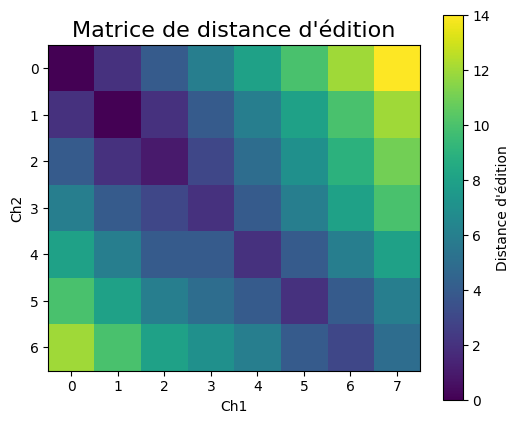

In [27]:
import numpy as np
import plotly.graph_objects as go

def StringEditDistance(ch1,ch2,cost):

        dist=np.empty((len(ch2)+1,len(ch1)+1),dtype=int)
        dist[0,0]=0
        # A compléter ...
        n = len(ch1)
        m = len(ch2)

        for i in range(n+1):
                dist[0, i] = i * cost['del']  
        for j in range(m+1):
                dist[j, 0] = j * cost['ins']

        for j in range(1, m+1):
                for i in range(1, n+1):
                        if ch1[i-1] == ch2[j-1]:
                                sub_cost = 0
                        else:
                                sub_cost = cost['sub']
                        dist[j, i] = min(
                                dist[j, i-1] + cost['del'],   
                                dist[j-1, i] + cost['ins'],    
                                dist[j-1, i-1] + sub_cost        
                        )
        
        cout = dist[m, n]
        return cout, dist
        
    
cost={'ins': 2, 'del':2,'sub':1}
cout, dist = StringEditDistance("minimum","maxima",cost)

print("Matrice distance :") 
print(dist)
print("==> Cout = ", cout)

# Affihcer la matrice  distance 
# A compléter ...

plt.figure(figsize=(6, 5))
plt.imshow(dist, cmap='viridis', origin='upper')
plt.colorbar(label='Distance d\'édition')
plt.title("Matrice de distance d'édition", fontsize=16)
plt.xlabel("Ch1")
plt.ylabel("Ch2")
plt.show()

## Plongement de chaînes

On suppose que l'on dispose d'un fichier contenant la liste de vos prénoms avec un prénom par ligne.  Ce fichier est chargé par la fonction loadNames() fournie. 

In [28]:
def loadNames(file):
    l=[]
    with open(file,"r") as f:
        l=f.readlines()
    l=[n[:-1] for n in l]
    return l

Utilisez la liste des prénoms fournie par la fonction loadNames() pour calculer la matrice de distance entre toutes les paires de prénoms. En se basant sur le cours calculer la matrice de produit scalaire associée (S) puis les coordonnées x et y correspondant aux deux coordonnées de plus grandes valeurs propres de la matrice X codant le plongement. A partir des coordonnées x et y faire un plot en affichant chaque  prénom à ses  coordonnées (x,y).  Le calcul du graphique à partir de la matrice de distance se fera dans la fonction display() à compléter. 

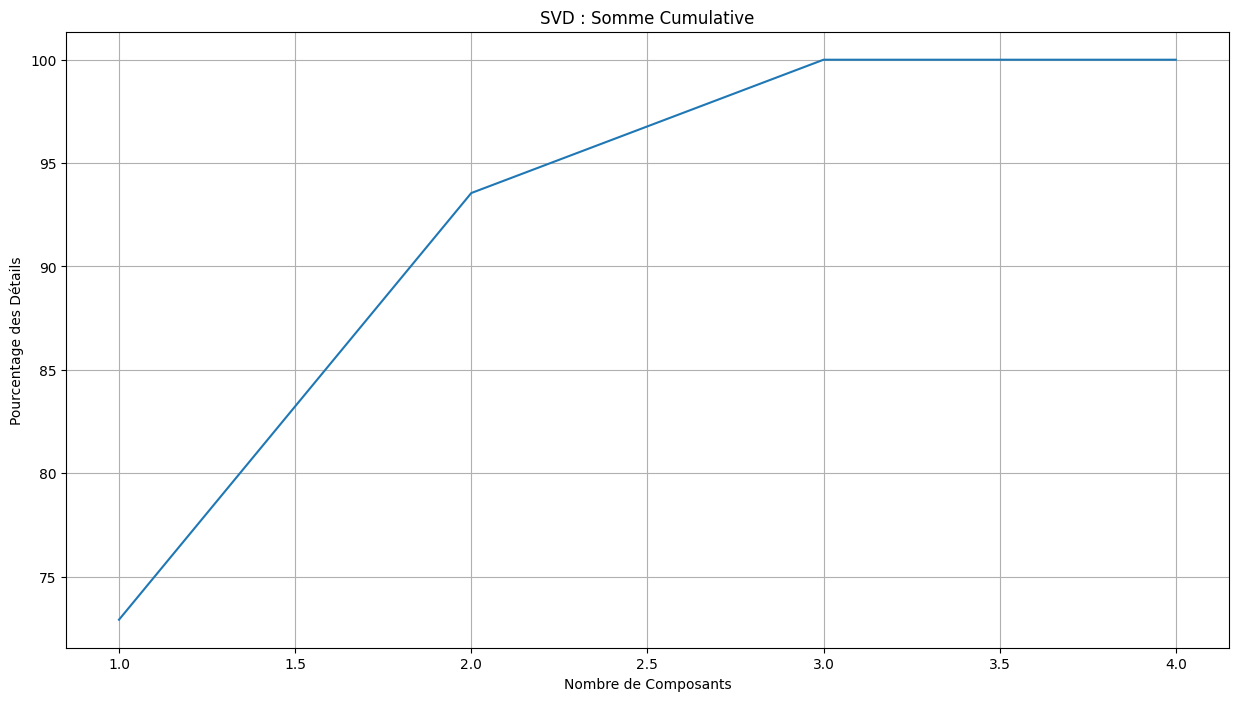

In [33]:
# names = loadNames("names1.txt")
names = loadNames("images/list.txt")
nb = len(names)

# Init.  distances
distances = np.zeros((nb, nb), dtype=int)

# Calculer la matrice de distances entre les différents noms  ==> distances
# A compléter ...  
cost={'ins': 2, 'del':2,'sub':1}

for i in range(nb):
    for j in range(i, nb):
        _, d = StringEditDistance(names[i], names[j], cost)
        distances[j, i] = min(
                dist[j, i-1] + cost['del'],    # suppression
                dist[j-1, i] + cost['ins'],    # insertion
                dist[j-1, i-1]     # substitution
            )

# SVD 1 - Somme cumulative des valeurs singulières
# A compléter ...
U, S, Vt = np.linalg.svd(distances)
S_cumsum = np.cumsum(S) / np.sum(S) * 100

plt.figure()
plt.plot(range(1, len(S) + 1), S_cumsum)
plt.xlabel("Nombre de Composants")
plt.ylabel("Pourcentage des Détails")
plt.title("SVD : Somme Cumulative")
plt.grid()
plt.show()



In [34]:
from sklearn.manifold import MDS

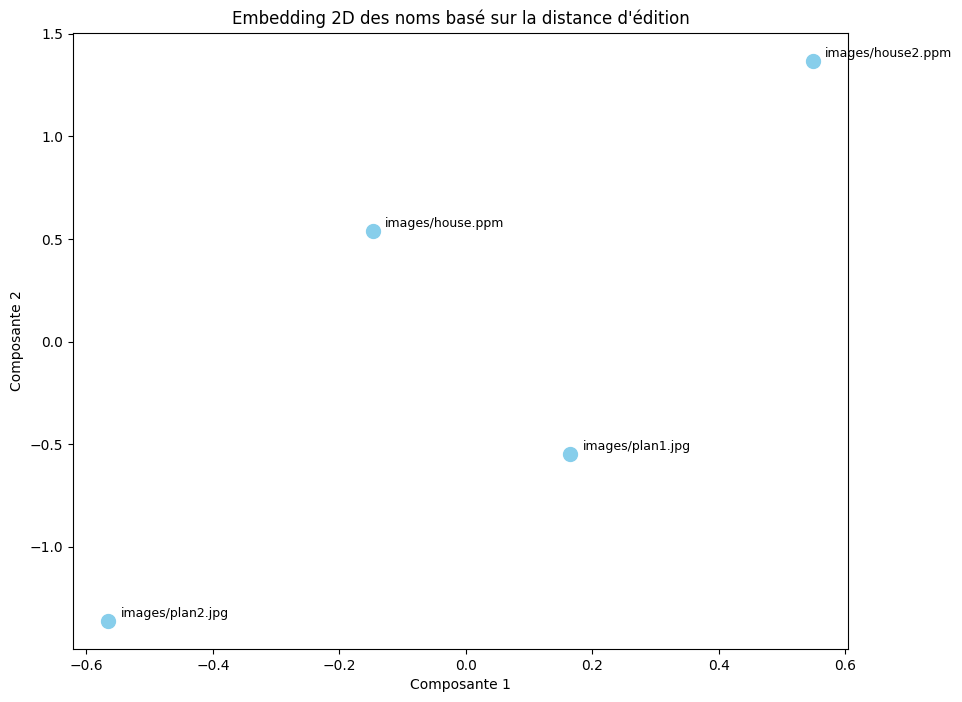

In [38]:
# A compléter ...

# Faaire appel à la fonction StringEditDistance pour calculer la distance entre deux 

def display(distance,names):
    # A compléter ...
    # Faire la décomposition en valeurs singulières (SVD) de la matrice de distance **
    # Avec une matrice de distance, il est possible de calculer une représentation vectorielle (embedding) des données en utilisant des techniques basées sur la matrice de distance.
    # Une méthode courante est la Multidimensional Scaling (MDS) qui vise à trouver une représentation en basse dimension des données tout en préservant les distances entre les points
    # Elle n'est généralement pas directement applicable à une matrice de distance telle quelle ==> On peut faire des transformations (normalisations) telles que :
    # Matrice d'affinité, Matrice Laplacienne ...
    # A compléter ...
    nb = len(names)
    distance = (distance + distance.T) / 2
    
    # --- Multidimensional Scaling (MDS) ---
    # Permet de reconstruire une représentation 2D à partir des distances
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    embedding = mds.fit_transform(distance)  # shape (nb, 2)
    
    # --- Affichage ---
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c='skyblue', s=100)
    
    # Ajouter les labels (noms) sur le scatter
    for i, name in enumerate(names):
        plt.text(embedding[i, 0]+0.02, embedding[i, 1]+0.02, name, fontsize=9)
    
    plt.xlabel("Composante 1")
    plt.ylabel("Composante 2")
    plt.title("Embedding 2D des noms basé sur la distance d'édition")
    plt.show()

     
#print(names)
#print (distances)
display(distances,names)

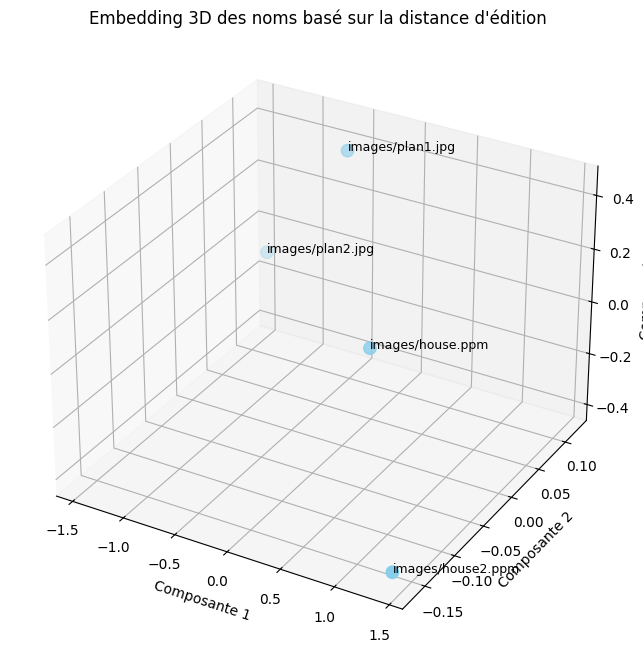

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D  # Nécessaire pour 3D

def display_3d(distance, names):
    """
    Affiche un embedding 3D des noms à partir de la matrice de distance.
    """
    nb = len(names)
    
    # --- Forcer la symétrie exacte de la matrice ---
    distance = (distance + distance.T) / 2
    
    # --- Multidimensional Scaling (MDS) en 3D ---
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
    embedding = mds.fit_transform(distance)  # shape (nb, 3)
    
    # --- Affichage 3D ---
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2],
               c='skyblue', s=80, depthshade=True)
    
    # Ajouter les labels
    for i, name in enumerate(names):
        ax.text(embedding[i, 0], embedding[i, 1], embedding[i, 2],
                name, fontsize=9)
    
    ax.set_xlabel("Composante 1")
    ax.set_ylabel("Composante 2")
    ax.set_zlabel("Composante 3")
    ax.set_title("Embedding 3D des noms basé sur la distance d'édition")
    plt.show()

display_3d(distances, names)

In [40]:
import plotly.graph_objects as go
from sklearn.manifold import MDS
import numpy as np

def display_3dP(distance, names):
    """
    Affiche un embedding 3D interactif des noms basé sur la matrice de distance
    en utilisant Plotly.
    """
    # Forcer la symétrie exacte
    distance = (distance + distance.T) / 2

    # --- MDS 3D ---
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
    embedding = mds.fit_transform(distance)  # shape (nb, 3)

    # --- Création de la figure Plotly ---
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=embedding[:, 0],
        y=embedding[:, 1],
        z=embedding[:, 2],
        mode='markers+text',
        text=names,
        textposition='top center',
        marker=dict(
            size=6,
            color='skyblue',
            opacity=0.8
        )
    ))

    # Mise en forme du layout
    fig.update_layout(
        scene=dict(
            xaxis_title='Composante 1',
            yaxis_title='Composante 2',
            zaxis_title='Composante 3'
        ),
        title='Embedding 3D interactif des noms basé sur la distance d\'édition',
        width=900,
        height=700
    )

    fig.show()

In [41]:
display_3dP(distances, names)

##  Optionnel : Vous pouvez  :
    - Utiliser une approche interactive pour le choix  des paramètres 
    - Utiliser plusieurs métriques appropriés aux données (texte) à tester et comparer
    - Utiliser plusieurs normalisations du noyau (distances) 
    - Afficher graphique 3D de chaque noyau ===> Comparaisons